# Recommendation system for products on an e-commerce website

Problem Statement -
Build your own recommendation system for products on an e-commerce website like Amazon.com. 

Dataset columns - first three columns are userId, productId, and ratings and the fourth column is timestamp. You can discard the timestamp column as in this case you may not need to use it.

Source - Amazon Reviews data (http://jmcauley.ucsd.edu/data/amazon/).
Dataset Link - https://drive.google.com/file/d/1ClBptsK3V5KgKXtK2GSRzFNAW7GnTPDW/view?usp=sharing 

In [8]:
%matplotlib inline

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import numpy as np
import time
from sklearn.externals import joblib
import matplotlib.pyplot as plt

## Read and explore the given dataset (Rename column/add headers, plot histograms, find data characteristics)

In [9]:
# Load the data file
ratings_file  = 'ratings_Electronics.csv'
ratings_df = pd.read_csv(ratings_file)

In [10]:
# Add column-names to the data 
ratings_df.columns = ['user_id', 'product_id', 'rating', 'timestamp']
ratings_df.shape

(7824481, 4)

In [11]:
# Prune the data, as its large and CPU is spinning, without coming out
num_rows = ratings_df.shape[0]
ratings_df = ratings_df.head(int(num_rows/100))
ratings_df.shape

(78244, 4)

In [12]:
# Check the data-frame table 
ratings_df.head()

,user_id,product_id,rating,timestamp
0,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
1,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
2,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
3,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200
4,A1QGNMC6O1VW39,0511189877,5.0,1397433600


In [13]:
# Display the dataframe rows/cols/dtypes
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78244 entries, 0 to 78243
Data columns (total 4 columns):
user_id       78244 non-null object
product_id    78244 non-null object
rating        78244 non-null float64
timestamp     78244 non-null int64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.4+ MB


In [14]:
# Drop timestamp, as it will not be used for the recommendation 
ratings_df = ratings_df.drop(["timestamp"], axis=1)

In [15]:
# check the unique number of users in the dataset
users = ratings_df['user_id'].unique()
len(users)

71280

In [16]:
# Check the unique number of products in the dataset
products = ratings_df['product_id'].unique()
len(products)

5554

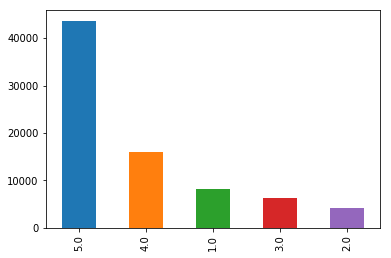

In [17]:
# Plot the distribution of the ratings in the datset
ratings_df['rating'].value_counts().plot(kind = 'bar')

## Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )

In [18]:
# Check the number of users who have given more than 50 ratings. 
user_id_group_rating = ratings_df.groupby('user_id')['rating'].count().clip(upper=50)
len(user_id_group_rating)

71280

#### As the num-of-unique-users and the num-of-users with >50 num-ratings is same, we don't need to prune further  

## Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio)

In [19]:
train_data, test_data = train_test_split(ratings_df, test_size = 0.30, random_state=100)
print(train_data.head(5))

              user_id  product_id  rating
1490   A1S7ZYV8AP9QUF  1400501466     4.0
14042  A26FYKG5LAHRUH  B00000JBIA     1.0
31975   A33Q24V2ALJH7  B00002SSVY     4.0
45026   AS87JUTBIDTN4  B00004T8R2     5.0
3227   A2QARZA980DE7S  1400666937     4.0


## Build Popularity Recommender model

In [20]:
#Class for Popularity based Recommender System model
class popularity_recommender_py():
    def __init__(self):
        self.train_data = None
        self.user_id = None
        self.item_id = None
        self.popularity_recommendations = None
        
    #Create the popularity based recommender system model
    def create(self, train_data, user_id, item_id):
        self.train_data = train_data
        self.user_id = user_id
        self.item_id = item_id

        #Get a count of user_ids for each unique song as recommendation score
        train_data_grouped = train_data.groupby([self.item_id]).agg({self.user_id: 'count'}).reset_index()
        train_data_grouped.rename(columns = {'user_id': 'score'},inplace=True)
    
        #Sort the songs based upon recommendation score
        train_data_sort = train_data_grouped.sort_values(['score', self.item_id], ascending = [0,1])
    
        #Generate a recommendation rank based upon score
        train_data_sort['Rank'] = train_data_sort['score'].rank(ascending=0, method='first')
        
        #Get the top 10 recommendations
        self.popularity_recommendations = train_data_sort.head(10)

    #Use the popularity based recommender system model to
    #make recommendations
    def recommend(self, user_id):    
        user_recommendations = self.popularity_recommendations
        
        #Add user_id column for which the recommendations are being generated
        user_recommendations['user_id'] = user_id
    
        #Bring user_id column to the front
        cols = user_recommendations.columns.tolist()
        cols = cols[-1:] + cols[:-1]
        user_recommendations = user_recommendations[cols]
        
        return user_recommendations

### Create an instance of popularity based recommender class

In [21]:
# Use the popularity recommendation class to create the model 
pm = popularity_recommender_py()
pm.create(train_data, 'user_id', 'product_id')

### Use the popularity model to make some predictions

In [22]:
# Predict the popularity-recommendation for different users.
user_id = users[7]
pm.recommend(user_id)

,user_id,product_id,score,Rank
4540,A34ATBPOK6HCHY,B00004ZCJE,1794,1.0
1785,A34ATBPOK6HCHY,B00001P4ZH,1452,2.0
2863,A34ATBPOK6HCHY,B00004T8R2,1218,3.0
1911,A34ATBPOK6HCHY,B00001WRSJ,1065,4.0
31,A34ATBPOK6HCHY,0972683275,750,5.0
2574,A34ATBPOK6HCHY,B00004SABB,746,6.0
2580,A34ATBPOK6HCHY,B00004SB92,690,7.0
2996,A34ATBPOK6HCHY,B00004THCZ,552,8.0
4128,A34ATBPOK6HCHY,B00004Z5M1,550,9.0
4490,A34ATBPOK6HCHY,B00004ZC8Y,514,10.0


In [23]:
# Predict the popularity-recommendation for different users.
user_id = users[20]
pm.recommend(user_id)

,user_id,product_id,score,Rank
4540,A2AW1SSVUIYV9Y,B00004ZCJE,1794,1.0
1785,A2AW1SSVUIYV9Y,B00001P4ZH,1452,2.0
2863,A2AW1SSVUIYV9Y,B00004T8R2,1218,3.0
1911,A2AW1SSVUIYV9Y,B00001WRSJ,1065,4.0
31,A2AW1SSVUIYV9Y,0972683275,750,5.0
2574,A2AW1SSVUIYV9Y,B00004SABB,746,6.0
2580,A2AW1SSVUIYV9Y,B00004SB92,690,7.0
2996,A2AW1SSVUIYV9Y,B00004THCZ,552,8.0
4128,A2AW1SSVUIYV9Y,B00004Z5M1,550,9.0
4490,A2AW1SSVUIYV9Y,B00004ZC8Y,514,10.0


#### As seen above, the popularity recommendation model predicts the is same for all the users 

## Build Collaborative Filtering model

In [24]:
#Class for Item similarity based Recommender System model
class item_similarity_recommender_py():
    def __init__(self):
        self.train_data = None
        self.user_id = None
        self.item_id = None
        self.cooccurence_matrix = None
        self.songs_dict = None
        self.rev_songs_dict = None
        self.item_similarity_recommendations = None
        
    #Get unique items (songs) corresponding to a given user
    def get_user_items(self, user):
        user_data = self.train_data[self.train_data[self.user_id] == user]
        user_items = list(user_data[self.item_id].unique())
        
        return user_items
        
    #Get unique users for a given item (song)
    def get_item_users(self, item):
        item_data = self.train_data[self.train_data[self.item_id] == item]
        item_users = set(item_data[self.user_id].unique())
            
        return item_users
        
    #Get unique items (songs) in the training data
    def get_all_items_train_data(self):
        all_items = list(self.train_data[self.item_id].unique())
            
        return all_items
        
    #Construct cooccurence matrix
    def construct_cooccurence_matrix(self, user_songs, all_songs):
            
        ####################################
        #Get users for all songs in user_songs.
        ####################################
        user_songs_users = []        
        for i in range(0, len(user_songs)):
            user_songs_users.append(self.get_item_users(user_songs[i]))
            
        ###############################################
        #Initialize the item cooccurence matrix of size 
        #len(user_songs) X len(songs)
        ###############################################
        cooccurence_matrix = np.matrix(np.zeros(shape=(len(user_songs), len(all_songs))), float)
           
        #############################################################
        #Calculate similarity between user songs and all unique songs
        #in the training data
        #############################################################
        for i in range(0,len(all_songs)):
            #Calculate unique listeners (users) of song (item) i
            songs_i_data = self.train_data[self.train_data[self.item_id] == all_songs[i]]
            users_i = set(songs_i_data[self.user_id].unique())
            
            for j in range(0,len(user_songs)):       
                    
                #Get unique listeners (users) of song (item) j
                users_j = user_songs_users[j]
                    
                #Calculate intersection of listeners of songs i and j
                users_intersection = users_i.intersection(users_j)
                
                #Calculate cooccurence_matrix[i,j] as Jaccard Index
                if len(users_intersection) != 0:
                    #Calculate union of listeners of songs i and j
                    users_union = users_i.union(users_j)
                    
                    cooccurence_matrix[j,i] = float(len(users_intersection))/float(len(users_union))
                else:
                    cooccurence_matrix[j,i] = 0
                    
        
        return cooccurence_matrix

    
    #Use the cooccurence matrix to make top recommendations
    def generate_top_recommendations(self, user, cooccurence_matrix, all_songs, user_songs):
        print("Non zero values in cooccurence_matrix :%d" % np.count_nonzero(cooccurence_matrix))
        
        #Calculate a weighted average of the scores in cooccurence matrix for all user songs.
        user_sim_scores = cooccurence_matrix.sum(axis=0)/float(cooccurence_matrix.shape[0])
        user_sim_scores = np.array(user_sim_scores)[0].tolist()
 
        #Sort the indices of user_sim_scores based upon their value
        #Also maintain the corresponding score
        sort_index = sorted(((e,i) for i,e in enumerate(list(user_sim_scores))), reverse=True)
    
        #Create a dataframe from the following
        columns = ['user_id', 'product_id', 'score', 'rank']
        #index = np.arange(1) # array of numbers for the number of samples
        df = pd.DataFrame(columns=columns)
         
        #Fill the dataframe with top 10 item based recommendations
        rank = 1 
        for i in range(0,len(sort_index)):
            if ~np.isnan(sort_index[i][0]) and all_songs[sort_index[i][1]] not in user_songs and rank <= 10:
                df.loc[len(df)]=[user,all_songs[sort_index[i][1]],sort_index[i][0],rank]
                rank = rank+1
        
        #Handle the case where there are no recommendations
        if df.shape[0] == 0:
            print("The current user has no products for training the item similarity based recommendation model.")
            return -1
        else:
            return df
 
    #Create the item similarity based recommender system model
    def create(self, train_data, user_id, item_id):
        self.train_data = train_data
        self.user_id = user_id
        self.item_id = item_id

    #Use the item similarity based recommender system model to
    #make recommendations
    def recommend(self, user):
        
        ########################################
        #A. Get all unique songs for this user
        ########################################
        user_songs = self.get_user_items(user)    
            
        print("No. of unique products for the user: %d" % len(user_songs))
        
        ######################################################
        #B. Get all unique items (songs) in the training data
        ######################################################
        all_songs = self.get_all_items_train_data()
        
        print("no. of unique products in the training set: %d" % len(all_songs))
         
        ###############################################
        #C. Construct item cooccurence matrix of size 
        #len(user_songs) X len(songs)
        ###############################################
        cooccurence_matrix = self.construct_cooccurence_matrix(user_songs, all_songs)
        
        #######################################################
        #D. Use the cooccurence matrix to make recommendations
        #######################################################
        df_recommendations = self.generate_top_recommendations(user, cooccurence_matrix, all_songs, user_songs)
                
        return df_recommendations
    
    #Get similar items to given items
    def get_similar_items(self, item_list):
        
        user_songs = item_list
        
        ######################################################
        #B. Get all unique items (songs) in the training data
        ######################################################
        all_songs = self.get_all_items_train_data()
        
        print("no. of unique products in the training set: %d" % len(all_songs))
         
        ###############################################
        #C. Construct item cooccurence matrix of size 
        #len(user_songs) X len(songs)
        ###############################################
        cooccurence_matrix = self.construct_cooccurence_matrix(user_songs, all_songs)
        
        #######################################################
        #D. Use the cooccurence matrix to make recommendations
        #######################################################
        user = ""
        df_recommendations = self.generate_top_recommendations(user, cooccurence_matrix, all_songs, user_songs)
         
        return df_recommendations

### Create an instance of item similarity based recommender class

In [25]:
# Use the item similarity model for collaorative filtering 
is_model = item_similarity_recommender_py()
is_model.create(train_data, 'user_id', 'product_id')

### Use the personalized model to make some product recommendations

In [26]:
#Print the products for the user in training data
user_id = users[1]
user_items = is_model.get_user_items(user_id)

#
print("------------------------------------------------------------------------------------")
print("Training data products for the user userid: %s:" % user_id)
print("------------------------------------------------------------------------------------")

for user_item in user_items:
    print(user_item)

print("----------------------------------------------------------------------")
print("Recommendation process going on:")
print("----------------------------------------------------------------------")

#Recommend songs for the user using personalized model
is_model.recommend(user_id)

------------------------------------------------------------------------------------
Training data products for the user userid: A2NWSAGRHCP8N5:
------------------------------------------------------------------------------------
0439886341
----------------------------------------------------------------------
Recommendation process going on:
----------------------------------------------------------------------
No. of unique products for the user: 1
no. of unique products in the training set: 4923
Non zero values in cooccurence_matrix :1


,user_id,product_id,score,rank
0,A2NWSAGRHCP8N5,9985580079,0.0,1
1,A2NWSAGRHCP8N5,B00001OPK4,0.0,2
2,A2NWSAGRHCP8N5,B00004U8JN,0.0,3
3,A2NWSAGRHCP8N5,B00000K4L0,0.0,4
4,A2NWSAGRHCP8N5,B00003006Q,0.0,5
5,A2NWSAGRHCP8N5,9875908576,0.0,6
6,A2NWSAGRHCP8N5,B00004Z7QL,0.0,7
7,A2NWSAGRHCP8N5,B00001ZUHL,0.0,8
8,A2NWSAGRHCP8N5,9983900637,0.0,9
9,A2NWSAGRHCP8N5,0594450705,0.0,10


## Evaluate both the models. ( Once the model is trained on the training data, it can be used to compute the error (like RMSE) on predictions made on the test data.) You can also use a different method to evaluate the models.

In [27]:
#Class to calculate precision and recall

import random

class precision_recall_calculator():
    
    def __init__(self, test_data, train_data, pm, is_model):
        self.test_data = test_data
        self.train_data = train_data
        self.user_test_sample = None
        self.model1 = pm
        self.model2 = is_model
        
        self.ism_training_dict = dict()
        self.pm_training_dict = dict()
        self.test_dict = dict()
    
    #Method to return random percentage of values from a list
    def remove_percentage(self, list_a, percentage):
        k = int(len(list_a) * percentage)
        random.seed(0)
        indicies = random.sample(range(len(list_a)), k)
        new_list = [list_a[i] for i in indicies]
    
        return new_list
    
    #Create a test sample of users for use in calculating precision
    #and recall
    def create_user_test_sample(self, percentage):
        #Find users common between training and test set
        users_test_and_training = list(set(self.test_data['user_id'].unique()).intersection(set(self.train_data['user_id'].unique())))
        print("Length of user_test_and_training:%d" % len(users_test_and_training))

        #Take only random user_sample of users for evaluations
        self.users_test_sample = self.remove_percentage(users_test_and_training, percentage)

        print("Length of user sample:%d" % len(self.users_test_sample))
        
    #Method to generate recommendations for users in the user test sample
    def get_test_sample_recommendations(self):
        #For these test_sample users, get top 10 recommendations from training set
        #self.ism_training_dict = {}
        #self.pm_training_dict = {}

        #self.test_dict = {}

        for user_id in self.users_test_sample:
            #Get items for user_id from item similarity model
            print("Getting recommendations for user:%s" % user_id)
            user_sim_items = self.model2.recommend(user_id)
            self.ism_training_dict[user_id] = list(user_sim_items['product_id'])
            
            #Get items for user_id from popularity model
            user_sim_items = self.model1.recommend(user_id)
            self.pm_training_dict[user_id] = list(user_sim_items['product_id'])
            
    
            #Get items for user_id from test_data
            test_data_user = self.test_data[self.test_data['user_id'] == user_id]
            self.test_dict[user_id] = set(test_data_user['product_id'].unique() )
            
    
    #Method to calculate the precision and recall measures
    def calculate_precision_recall(self):
        #Create cutoff list for precision and recall calculation
        cutoff_list = list(range(1,11))


        #For each distinct cutoff:
        #    1. For each distinct user, calculate precision and recall.
        #    2. Calculate average precision and recall.

        ism_avg_precision_list = []
        ism_avg_recall_list = []
        pm_avg_precision_list = []
        pm_avg_recall_list = []


        num_users_sample = len(self.users_test_sample)
        for N in cutoff_list:
            ism_sum_precision = 0
            ism_sum_recall = 0
            pm_sum_precision = 0
            pm_sum_recall = 0
            ism_avg_precision = 0
            ism_avg_recall = 0
            pm_avg_precision = 0
            pm_avg_recall = 0

            for user_id in self.users_test_sample:
                ism_hitset = self.test_dict[user_id].intersection(set(self.ism_training_dict[user_id][0:N]))
                pm_hitset = self.test_dict[user_id].intersection(set(self.pm_training_dict[user_id][0:N]))
                testset = self.test_dict[user_id]
        
                pm_sum_precision += float(len(pm_hitset))/float(N)
                pm_sum_recall += float(len(pm_hitset))/float(len(testset))

                ism_sum_precision += float(len(ism_hitset))/float(len(testset))
                ism_sum_recall += float(len(ism_hitset))/float(N)
        
            pm_avg_precision = pm_sum_precision/float(num_users_sample)
            pm_avg_recall = pm_sum_recall/float(num_users_sample)
    
            ism_avg_precision = ism_sum_precision/float(num_users_sample)
            ism_avg_recall = ism_sum_recall/float(num_users_sample)

            ism_avg_precision_list.append(ism_avg_precision)
            ism_avg_recall_list.append(ism_avg_recall)
    
            pm_avg_precision_list.append(pm_avg_precision)
            pm_avg_recall_list.append(pm_avg_recall)
            
        return (pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list)
     

    #A wrapper method to calculate all the evaluation measures
    def calculate_measures(self, percentage):
        #Create a test sample of users
        self.create_user_test_sample(percentage)
        
        #Generate recommendations for the test sample users
        self.get_test_sample_recommendations()
        
        #Calculate precision and recall at different cutoff values
        #for popularity mode (pm) as well as item similarity model (ism)
        
        return self.calculate_precision_recall()
        #return (pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list)    

### Model Prediction using precision and recall 

In [28]:
#Instantiate the precision_recall_calculator class
pr = precision_recall_calculator(test_data, train_data, pm, is_model)

In [29]:
#Define what percentage of users to use for precision recall calculation
user_sample = 0.01

#Call method to calculate precision and recall values
(pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list) = pr.calculate_measures(user_sample)

Length of user_test_and_training:2064
Length of user sample:20
Getting recommendations for user:AYLC085ZL5X5O
No. of unique products for the user: 2
no. of unique products in the training set: 4923
Non zero values in cooccurence_matrix :22
Getting recommendations for user:A3KYYFT538CZ0O
No. of unique products for the user: 10
no. of unique products in the training set: 4923
Non zero values in cooccurence_matrix :194
Getting recommendations for user:A2RWI6T2LP0BM1
No. of unique products for the user: 2
no. of unique products in the training set: 4923
Non zero values in cooccurence_matrix :106
Getting recommendations for user:A36TON3TN62DO9
No. of unique products for the user: 1
no. of unique products in the training set: 4923
Non zero values in cooccurence_matrix :52
Getting recommendations for user:ASB2KK5C22P6H
No. of unique products for the user: 1
no. of unique products in the training set: 4923
Non zero values in cooccurence_matrix :10
Getting recommendations for user:A1BQX78OKLHGT

In [30]:
import pylab as pl

#Method to generate precision and recall curve
def plot_precision_recall(m1_precision_list, m1_recall_list, m1_label, m2_precision_list, m2_recall_list, m2_label):
    pl.clf()    
    pl.plot(m1_recall_list, m1_precision_list, label=m1_label)
    pl.plot(m2_recall_list, m2_precision_list, label=m2_label)
    pl.xlabel('Recall')
    pl.ylabel('Precision')
    pl.ylim([0.0, 0.2])
    pl.xlim([0.0, 0.2])
    pl.title('Precision-Recall curve')
    #pl.legend(loc="upper right")
    pl.legend(loc=9, bbox_to_anchor=(0.5, -0.2))
    pl.show()

Plotting precision recall curves.


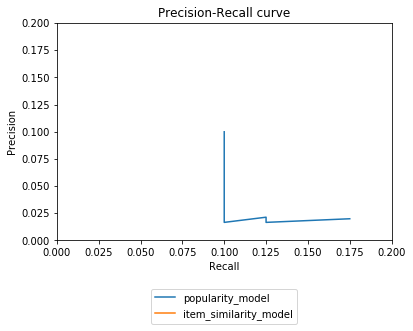

In [31]:
print("Plotting precision recall curves.")

plot_precision_recall(pm_avg_precision_list, pm_avg_recall_list, "popularity_model",
                      ism_avg_precision_list, ism_avg_recall_list, "item_similarity_model")

## Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.

###  Use surprise package to do the collaborative filtering and get the top 5 recommendations 

In [32]:
# Import the surprise python package. For this, we need to first install surprise package in anaconda 
from surprise import SVD
from surprise import Dataset
from surprise.model_selection import cross_validate
from surprise import NormalPredictor
from surprise import Dataset
from surprise import Reader
from surprise.model_selection import train_test_split
from surprise import accuracy
from collections import defaultdict

In [33]:
# Function to get the top-N product predictions for the user 
def get_top_n(predictions, n=10):
    '''Return the top-N recommendation for each user from a set of predictions.

    Args:
        predictions(list of Prediction objects): The list of predictions, as
            returned by the test method of an algorithm.
        n(int): The number of recommendation to output for each user. Default
            is 10.

    Returns:
    A dict where keys are user (raw) ids and values are lists of tuples:
        [(raw item id, rating estimation), ...] of size n.
    '''

    # First map the predictions to each user.
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [34]:
ratings_df.shape

(78244, 3)

In [35]:
# Read the dataframe into the surprise data-loader
reader = Reader()
data = Dataset.load_from_df(ratings_df[['user_id', 'product_id', 'rating']], reader)

In [36]:
# Do a train-test split using surprise 
train_data, test_data = train_test_split(data, test_size = 0.30, random_state=100)

In [37]:
# We'll use the SVD algorithm.
algo = SVD()

# Train the algorithm on the trainset, and predict ratings for the testset
algo.fit(train_data)
predictions = algo.test(test_data)

# Run 4-fold cross-validation and print results
cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=4, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 4 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Mean    Std     
RMSE (testset)    1.2757  1.2656  1.2787  1.2687  1.2722  0.0052  
MAE (testset)     0.9981  0.9887  0.9990  0.9976  0.9959  0.0042  
Fit time          3.63    3.73    3.66    3.65    3.67    0.04    
Test time         0.12    0.12    0.13    0.12    0.12    0.00    


{'test_rmse': array([1.2757261 , 1.26562585, 1.27867186, 1.26871267]),
 'test_mae': array([0.99813963, 0.98872814, 0.99903043, 0.99760577]),
 'fit_time': (3.625999927520752,
  3.7279999256134033,
  3.6579999923706055,
  3.6520001888275146),
 'test_time': (0.12199997901916504,
  0.11899971961975098,
  0.12600016593933105,
  0.11899995803833008)}

In [38]:
# Predict the top-5 recommendations for all the test users using this function
predict_top_N = get_top_n(predictions, n=5)

In [39]:
# Prediction for all the 22544 test-users 
len(predict_top_N)

22544

## Summarise your insights.

#### Had to prune the data-set by doing div of 100. Otherwise the model was taking too long to run and getting stuck, when run in anaconda. 

#### For the Popularity based model, the product recommendations are the same for all the users. This is because, it's not user specific and only takes into account the popularity of the product

#### For collaborative filtering, we could see that the product recommendations were based on both user and content based. In this case, we have build a co-occurance matrix when we want to run the model for a user and displayed the product recommendations 

#### We have also evaluated the popularity and collaborative filtering based model performance using the precision/recall metrics and plotted the same for a sample of 0.01 users. 

#### We have used the Surprise package to again create/run a collaborative recommendation model. This is with SVD, which using matrix factorization. This is to demonstrate different methods of recommendation models for the same data-set 

In [41]:
# Top-5 product prediction for all the test users. Displaying here, as its a long list for 22,544 users 
predict_top_N

defaultdict(list,
            {'A12CF8A3O50IC0': [('B00004THCZ', 4.265495263145)],
             'AT5E064X2TLJX': [('B00004W3ZQ', 4.285166067347651)],
             'A3GTTII3IQTANG': [('B00004T8R2', 4.286071444107639)],
             'A1B5QBWIE6RWWM': [('B00004VXNI', 4.349410365005681)],
             'A3B9Z2K0I7MXTP': [('B00000J1QU', 4.281105363350101),
              ('B00000J1EQ', 4.2419758617901975),
              ('B00001OWYM', 3.1061392694417074)],
             'AUAH2BK4LJRC8': [('B00001WBRG', 3.307185153962742)],
             'A11MD044ZQRZ2U': [('B00004ZC8Y', 4.266792023365911)],
             'AR4AHYS4HHFGN': [('B00004TWM6', 3.425190133704687)],
             'A9SVHPGKKKOH1': [('B00004VUGJ', 4.234050948824594)],
             'A18QPM34SQVX8R': [('B00004ZC9V', 4.391129331647002)],
             'A3A8WS7CZ9IMML': [('B00004TVSP', 4.152725389909406)],
             'A23X08KRDJKF7': [('0972683275', 4.40986391231248)],
             'A3NRUB5I43LGK1': [('B00000JI46', 4.045171077015438)],
       